In [ ]:
from IPython import display

# Простейшие нейронные сети на PyTorch


PyTorch стал очень популярным благодаря интуитивно понятной парадигме программирования нейронных сетей, основанной на динамическом графе. Не так давно PyTorch создал свою экосистему https://pytorch.org/ecosystem/, которая содержит в себе библиотеки, решающие практически всевозможные задачи машинного обучения. 

Чтобы установить библиотеку PyTorch, отправляйтесь в консоль и пропишите 

```
Для Windows без GPU
pip install torch==1.6.0+cpu torchvision==0.7.0+cpu -f https://download.pytorch.org/whl/torch_stable.html

Для Windows c GPU
pip install torch==1.6.0+cu101 torchvision==0.7.0+cu101 -f https://download.pytorch.org/whl/torch_stable.html

Для Linux без GPU
pip install torch==1.6.0+cpu torchvision==0.7.0+cpu -f https://download.pytorch.org/whl/torch_stable.html

Для Linux c GPU
pip install torch==1.6.0+cu101 torchvision==0.7.0+cu101 -f https://download.pytorch.org/whl/torch_stable.html

Для Mac
pip install torch torchvision

pip install pytorch-lightning
```


In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Подгружаем pytorch 
import torch

print(torch.__version__)

2.8.0


In [3]:
# Подгрузим ещё немного пакетов :) 
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')

from sklearn.model_selection import train_test_split

%matplotlib inline

## 1. О данных и бэйзлайнах

Наша главная цель - познакомиться с процессом создания простой нейронной сети и ее обучения.

__Делать всё это мы будем на животных.__ Ежегодно около 7.6 миллионов бедных животных в США оказываются в приютах. Часть из них находит себе новую семью, часть возвращается к старому (бывает, что питомец потерялся и его нашли на улице), а часть погибает. Eжегодно усыпляется около 2.7 млн. собак и кошек.  

Используя датасет с входной информацией (цвет, пол, возраст и т.п.) из одного из приютов, мы попытаемся спрогнозировать что произойдёт с новыми животными, которые попадут в этот приют. Данные, используемые в тетрадке уже были предварительно обработаны и приведены в удобную для построения моделей форму. 

In [4]:
X = pd.read_csv('./data/X_cat.csv', sep = '\t', index_col = 0)
target = pd.read_csv('./data/y_cat.csv', sep = '\t', index_col = 0, names = ['status'])

print(X.shape)
X.head()

(26729, 37)


,IsDog,Age,HasName,NameLength,NameFreq,MixColor,ColorFreqAsIs,ColorFreqBase,TabbyColor,MixBreed,...,SexStatus_Flawed,SexStatus_Intact,SexStatus_Unknown,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6
0,1,365.0,1,7,0.000157,1,0.032919,0.463624,0,1,...,1,0,0,0,0,1,0,0,0,0
1,0,365.0,1,5,0.000655,0,0.008092,0.015005,1,1,...,1,0,0,0,0,0,0,0,0,1
2,1,730.0,1,6,0.000052,1,0.026293,0.357521,0,1,...,1,0,0,0,0,0,0,0,1,0
3,0,21.0,0,7,0.285871,0,0.000471,0.058418,0,1,...,0,1,0,0,0,0,0,1,0,0
4,1,730.0,0,7,0.285871,0,0.023831,0.075353,0,0,...,1,0,0,0,0,0,0,1,0,0


In [5]:
X.head(1)

,IsDog,Age,HasName,NameLength,NameFreq,MixColor,ColorFreqAsIs,ColorFreqBase,TabbyColor,MixBreed,...,SexStatus_Flawed,SexStatus_Intact,SexStatus_Unknown,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6
0,1,365.0,1,7,0.000157,1,0.032919,0.463624,0,1,...,1,0,0,0,0,1,0,0,0,0


In [6]:
X.head().T

,0,1,2,3,4
IsDog,1.000000,0.000000,1.000000,0.000000,1.000000
Age,365.000000,365.000000,730.000000,21.000000,730.000000
HasName,1.000000,1.000000,1.000000,0.000000,0.000000
NameLength,7.000000,5.000000,6.000000,7.000000,7.000000
NameFreq,0.000157,0.000655,0.000052,0.285871,0.285871
MixColor,1.000000,0.000000,1.000000,0.000000,0.000000
ColorFreqAsIs,0.032919,0.008092,0.026293,0.000471,0.023831
ColorFreqBase,0.463624,0.015005,0.357521,0.058418,0.075353
TabbyColor,0.000000,1.000000,0.000000,0.000000,0.000000
MixBreed,1.000000,1.000000,1.000000,1.000000,0.000000


In [7]:
target.iloc[:, :]

,status
0,Return_to_owner
1,Euthanasia
2,Adoption
3,Transfer
4,Transfer
...,...
26724,Transfer
26725,Transfer
26726,Adoption
26727,Transfer


In [8]:
target['status'].unique()

array(['Return_to_owner', 'Euthanasia', 'Adoption', 'Transfer', 'Died'],
      dtype=object)

In [9]:
target.shape

(26729, 1)

In [10]:
X.shape

(26729, 37)

В датасете находится около 27 тысяч наблюдений и 37 регрессоров. Посмотрим на то как выглядит распределение того, что произошло со зверятами по особям.

In [11]:
target.status.value_counts()

status
Adoption           10769
Transfer            9422
Return_to_owner     4786
Euthanasia          1555
Died                 197
Name: count, dtype: int64

Видим, что классы несбалансированы. Попробуем оставить четыре класса и объединить класс умерших животных с классом животных, которых усыпили. 

In [12]:
target = target.iloc[:, :]
target[target == 'Died'] = 'Euthanasia'

In [13]:
target.status.value_counts()

status
Adoption           10769
Transfer            9422
Return_to_owner     4786
Euthanasia          1752
Name: count, dtype: int64

Закодируем классы.

In [14]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(target)
y

array([2, 1, 0, ..., 0, 3, 3])

In [15]:
len(y)

26729

In [16]:
X.shape

(26729, 37)

In [17]:
y

array([2, 1, 0, ..., 0, 3, 3])

In [21]:
pd.DataFrame(y)[0].unique()

array([2, 1, 0, 3])

In [22]:
X

,IsDog,Age,HasName,NameLength,NameFreq,MixColor,ColorFreqAsIs,ColorFreqBase,TabbyColor,MixBreed,...,SexStatus_Flawed,SexStatus_Intact,SexStatus_Unknown,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6
0,1,365.0,1,7,0.000157,1,0.032919,0.463624,0,1,...,1,0,0,0,0,1,0,0,0,0
1,0,365.0,1,5,0.000655,0,0.008092,0.015005,1,1,...,1,0,0,0,0,0,0,0,0,1
2,1,730.0,1,6,0.000052,1,0.026293,0.357521,0,1,...,1,0,0,0,0,0,0,0,1,0
3,0,21.0,0,7,0.285871,0,0.000471,0.058418,0,1,...,0,1,0,0,0,0,0,1,0,0
4,1,730.0,0,7,0.285871,0,0.023831,0.075353,0,0,...,1,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26724,0,30.0,0,7,0.285871,1,0.034909,0.463624,1,1,...,0,1,0,0,0,0,1,0,0,0
26725,0,90.0,0,7,0.285871,0,0.061778,0.164522,1,1,...,1,0,0,0,0,1,0,0,0,0
26726,1,1460.0,1,4,0.001571,1,0.014587,0.374455,0,1,...,1,0,0,1,0,0,0,0,0,0
26727,0,28.0,0,7,0.285871,0,0.085505,0.199270,0,1,...,0,1,0,0,0,0,0,0,0,1


Разобьём выборку на тренировочную и тестовую. 

In [23]:
y

array([2, 1, 0, ..., 0, 3, 3])

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

print(X_train.shape)
print(X_test.shape)

(21383, 37)
(5346, 37)


Прежде, чем учить 228-слойных монстров, давайте построим какие-нибудь простые прогнозы, чтобы было с чем сравнить. Давайте построи наивный прогноз, а также обучим линейную регрессию и случайный лес.

### Константный прогноз

Построим константный прогноз, чтобы было с чем сравнивать и прогноз по какой-нибудь модели. 

In [25]:
y_train

array([3, 3, 1, ..., 3, 3, 3])

In [26]:
from sklearn.metrics import log_loss

probas = np.array(pd.Series(y_train).value_counts(normalize = True).sort_index().tolist())
probas

array([0.40289015, 0.0655661 , 0.17906748, 0.35247627])

In [27]:
sum(probas)

0.9999999999999999

In [28]:
constant_forecast = np.tile(probas, X_test.shape[0]).reshape(X_test.shape[0], 4)
constant_forecast

array([[0.40289015, 0.0655661 , 0.17906748, 0.35247627],
       [0.40289015, 0.0655661 , 0.17906748, 0.35247627],
       [0.40289015, 0.0655661 , 0.17906748, 0.35247627],
       ...,
       [0.40289015, 0.0655661 , 0.17906748, 0.35247627],
       [0.40289015, 0.0655661 , 0.17906748, 0.35247627],
       [0.40289015, 0.0655661 , 0.17906748, 0.35247627]])

In [29]:
log_loss(y_test, constant_forecast)

1.22025524964878

### Логистическая регрессия

In [30]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
logreg.fit(X_train, y_train)
log_loss(y_test, logreg.predict_proba(X_test))

1.069063236360995

In [31]:
logreg.predict_proba(X_test) # 4 колонки, по одной на каждый класс

array([[0.18707812, 0.06706388, 0.04654057, 0.69931743],
       [0.7154717 , 0.02924001, 0.10843559, 0.1468527 ],
       [0.52378759, 0.03810541, 0.18066995, 0.25743704],
       ...,
       [0.77511351, 0.01025196, 0.17600585, 0.03862869],
       [0.22847285, 0.05775233, 0.03827041, 0.67550442],
       [0.66539471, 0.03012856, 0.1208298 , 0.18364694]])

### Случайный лес 

In [32]:
from sklearn.ensemble import RandomForestClassifier

In [33]:
rf = RandomForestClassifier(n_estimators = 1000, n_jobs = -1)
rf.fit(X_train, y_train)
log_loss(y_test, rf.predict_proba(X_test))

0.7555434644093678

In [34]:
help(RandomForestClassifier)

Help on class RandomForestClassifier in module sklearn.ensemble._forest:

class RandomForestClassifier(ForestClassifier)
 |  RandomForestClassifier(n_estimators=100, *, criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False, n_jobs=None, random_state=None, verbose=0, warm_start=False, class_weight=None, ccp_alpha=0.0, max_samples=None, monotonic_cst=None)
 |  
 |  A random forest classifier.
 |  
 |  A random forest is a meta estimator that fits a number of decision tree
 |  classifiers on various sub-samples of the dataset and uses averaging to
 |  improve the predictive accuracy and control over-fitting.
 |  Trees in the forest use the best split strategy, i.e. equivalent to passing
 |  `splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeRegressor`.
 |  The sub-sample size is controlled with the `max_samples` paramete

In [35]:
log_loss(y_train, rf.predict_proba(X_train))

0.18199997620985225

Неплохой результат. Попробуем улучшить его с помощью нейросеток. 

## 2. Собираем свою нейросеть

In [36]:
X_train.iloc[0]

IsDog                                0.000000
Age                                 30.000000
HasName                              0.000000
NameLength                           7.000000
NameFreq                             0.285871
MixColor                             0.000000
ColorFreqAsIs                        0.031086
ColorFreqBase                        0.034713
TabbyColor                           1.000000
MixBreed                             1.000000
Domestic                             1.000000
Shorthair                            1.000000
Longhair                             0.000000
Year                              2015.000000
Month                                8.000000
Day                                 25.000000
Hour                                12.300000
Breed_Chihuahua Shorthair Mix        0.000000
Breed_Domestic Medium Hair Mix       0.000000
Breed_Domestic Shorthair Mix         1.000000
Breed_German Shepherd Mix            0.000000
Breed_Labrador Retriever Mix      

In [37]:
INPUT_SIZE = 37
HIDDEN_SIZE = 25
OUTPUT_SIZE = 4
LEARNING_RATE = 1e-3
EPOCHS = 100
BATCH_SIZE = 128

# Vanilla PyTorch

Код представленный выше от fastai значительно упрощает работу с нейронными сетями, но не дает понять, что же происходит на самом деле. Поэтому на первых порах лучше все писать самим. Для этого обратимся к первоисточнику, а именно к оригинальному PyTorch, с которого все началось. И для начала разберем все этапы работы с нейронной сети в упрощенной форме. 

In [ ]:
# !pip install torchmetrics

In [47]:
from torchmetrics import Accuracy
import torch.nn as nn # содержит функции для реализации архитектуры нейронных сетей
import torch.nn.functional as F # содержит различные функции активации и не только
import torch.optim as optim
import torch.utils.data as data_utils

# from pytorch_lightning.metrics import Accuracy

Для того чтобы подавать данные в нейронную сеть, создадим `DataLoader`, который предоставляет гибкий API для работы с входными данными.

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X.iloc[:, :].values, y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

In [49]:
pd.Series(y).value_counts()

0    10769
3     9422
2     4786
1     1752
Name: count, dtype: int64

In [50]:
X_train.shape

(21383, 37)

In [51]:
100 * 168

16800

In [52]:
21383/128

167.0546875

Создание __DataLoader__ для обучения сети

In [53]:
def create_data_loader(X_train, y_train, X_test, y_test):
    train_tensor = data_utils.TensorDataset(torch.tensor(X_train.astype(np.float32)), torch.tensor(y_train))
    train_loader = data_utils.DataLoader(
        dataset = train_tensor,
        batch_size = BATCH_SIZE,
        shuffle = True
    )
    test_tensor = data_utils.TensorDataset(torch.tensor(X_test.astype(np.float32)), torch.tensor(y_test))
    test_loader = data_utils.DataLoader(
        dataset = test_tensor,
        batch_size = BATCH_SIZE,
        shuffle = False
    )
    return train_loader, test_loader

In [54]:
train_loader, test_loader = create_data_loader(X_train, y_train, X_test, y_test)

In [55]:
train_loader

In [56]:
test_loader

__Архитектура модели__

Архитектуру нейронной сети в PyTorch можно описать нескольками способами, в дальнейшем мы рассмотрим их более подробно. Сейчас предлагается сделать это используя `Sequential`.
`Sequential` -- это последовательный способ объявления каждой компоненты архитектуры нейронной сети.

In [57]:
INPUT_SIZE = 37 #Количество входных признаков или размерности входного вектора данных. Например, если у тебя есть набор данных с 37 признаками (features), то входной слой нейронной сети будет иметь 37 нейронов.
HIDDEN_SIZE = 25 #Количество нейронов в скрытом слое. Это параметр архитектуры сети, который определяет, сколько нейронов будет в одном из скрытых слоев.
OUTPUT_SIZE = 4 #Количество нейронов на выходном слое. Обычно это соответствует количеству классов в задаче классификации. Если у тебя 4 класса, то на выходе будет 4 нейрона, каждый из которых соответствует вероятности принадлежности к одному из этих классов.
LEARNING_RATE = 1e-3 #Скорость обучения. Это коэффициент, который определяет, насколько сильно обновляются веса сети на каждом шаге оптимизации. Меньшие значения приводят к более медленным, но потенциально более стабильным улучшениям.
EPOCHS = 100 #Количество эпох. Одна эпоха — это полный цикл прохождения всего тренировочного набора данных через модель. Здесь указано, что обучение будет продолжаться 100 эпох.
BATCH_SIZE = 128 #Размер батча. Это количество примеров из набора данных, которые сеть обрабатывает за один шаг перед обновлением весов. В данном случае модель обрабатывает 128 примеров одновременно, а затем обновляет свои параметры.

In [58]:
def build_model() :
    model = nn.Sequential(
        # Добавляем в нашу модель первый слой из 37 нейронов
        nn.Linear(in_features = INPUT_SIZE, out_features = HIDDEN_SIZE),
        nn.Sigmoid(),
        # Добавляем ещё один слой из 25 нейронов
        nn.Linear(in_features = HIDDEN_SIZE, out_features = HIDDEN_SIZE),
        nn.Sigmoid(),
        # Выходной вектор на количество классов, получаем с помощью такого же линейного приеобразования,
        # как и предыдущие слои, но уже на нужное количество выходных нейронов (т.е. классов)
        nn.Linear(in_features = HIDDEN_SIZE, out_features = OUTPUT_SIZE),
        nn.Softmax()
    )
    return model

Функция `Linear` представляет собой полносвязный слой, где присутствуют обучаемая матрица и обучаемый баес.

In [59]:
model = build_model()

In [60]:
print(model)

Sequential(
  (0): Linear(in_features=37, out_features=25, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=25, out_features=25, bias=True)
  (3): Sigmoid()
  (4): Linear(in_features=25, out_features=4, bias=True)
  (5): Softmax(dim=None)
)


На лекции была представлена возможная архитектура сети для задачи классификации. Сейчас мы тоже собрали свою сеть с одним скрытым слоем.

Обратите внимание, что последняя функция в в архитектуре сети -- это `Softmax`. Напомним, что `Softamx` используется для задачи классификации, чтобы получить значение увернности сети по каждому классу. Получается вектор на заданное количество классов, где наибольшее значение в какой-либо координате говорит о том, что сеть считает данный класс наиболее подходящим для данного наблюдения.

Отлично! Только что мы собрали свою первую нейросеть со скрытым слоем. Осталось ее обучить.

__Обучение модели__

Перед тем как обучать нашу нейросеть, нужно задать параметры обучения. 
- Во-первых, метод оптимизации. 
- Во-вторых, функцию потерь. 
- В-третьих, парочку метрик, на которые нам хотелось бы смотреть в процессе обучения.  

In [61]:
criterion = nn.CrossEntropyLoss()
accuracy = Accuracy(
    task = 'multiclass',
    num_classes = 4
)
optimizer = optim.SGD(model.parameters(), lr = LEARNING_RATE)

Создадим массивы, куда будем складывать значение целевой функции на обучающей и валиационной выборках, а также точность.

Ниже представлен код __обучения__ сети. Нужно обратить внимание на несколько моментов:
1. Обучение ведется в течение нескольких эпох -- что значит несколько проходов по выборке.
2. `train_loader` позволяет итеративно проходится по выборке и на каждой итерации получать батч заранее заданного размера.
3. На каждом шаге обнуляем градиенты `optimizer.zero_grad()`, чтобы не накапливать их, тем самым неккоректно обновлять веса.
4. Вызывать явно `loss.backward()` для вычисления градиентов.
5. Вызывать явно `optimizer.step()` для обновления весов.

In [62]:
step = 0
train_loss_values = []
train_accuracy_values = []
valid_loss_values = []
valid_accuracy = []

def run_train():
    step = 0
    for epoch in range(EPOCHS):
        running_loss = []
        running_acc = []
        for features, label in train_loader:
            # Reset gradients
            optimizer.zero_grad()
            output = model(features)
            # Calculate error and backpropagate
            loss = criterion(output, label)
            loss.backward()
            acc = accuracy(output, label).item()
            # Update weights with gradients
            optimizer.step()
            running_loss.append(loss.item())
            running_acc.append(acc)
            step += 1
        train_loss_values.append(np.mean(running_loss))
        train_accuracy_values.append(np.mean(running_acc))
        if epoch % 20 == 0:
            print('EPOCH %d : train_loss: %f' % (epoch, train_loss_values[-1]))#, train_accuracy_values[-1]))
        # Run validation
        running_loss = []
        running_acc = []
        for features, label in test_loader:
            output = model(features)
            # Calculate error and backpropagate
            loss = criterion(output, label)
            acc = accuracy(output, label).item()
            running_loss.append(loss.item())
            running_acc.append(acc)
        valid_loss_values.append(np.mean(running_loss))
        valid_accuracy.append(np.mean(running_acc))
        if epoch % 20 == 0:
            print('EPOCH %d : valid_loss: %f' % (epoch, valid_loss_values[-1]), (valid_accuracy[-1]))
    return train_loss_values, train_accuracy_values, valid_loss_values, valid_accuracy

In [63]:
train_loss_values, train_accuracy_values, valid_loss_values, valid_accuracy = run_train()

EPOCH 0 : train_loss: 1.364562
EPOCH 0 : valid_loss: 1.362464 0.35245459775129956
EPOCH 20 : train_loss: 1.315920
EPOCH 20 : valid_loss: 1.315584 0.40283345466568354
EPOCH 40 : train_loss: 1.303121
EPOCH 40 : valid_loss: 1.302885 0.40283345466568354
EPOCH 60 : train_loss: 1.298011
EPOCH 60 : valid_loss: 1.297979 0.40283345466568354
EPOCH 80 : train_loss: 1.295940
EPOCH 80 : valid_loss: 1.295346 0.40283345466568354


 Посмотрим на динамику ошибки и значение точности нашей модели во времени.

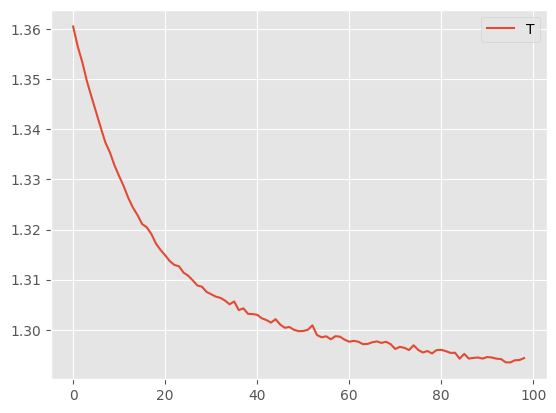

In [64]:
start = 1
plt.plot(train_loss_values[start:])
plt.legend('Train loss')